In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.axes import Axes
from matplotlib.lines import Line2D
from matplotlib.ticker import LogLocator, LogFormatterMathtext, NullFormatter



from qstr_diversity import core, viz

In [2]:
from qstr_dataset import paths
figpath = str(paths.figure("mean"))
h5_path_mean = paths.interim("amy_processeddata_mean.h5")

with pd.HDFStore(h5_path_mean, mode="r") as store:
    genmag_mean = store["/metrics/genmag"]
    spr_mean = store["/metrics/spread"]

In [3]:
genmag_mean

,1.000000e-04,1.412538e-04,1.995262e-04,2.818383e-04,3.981072e-04,5.623413e-04,7.943282e-04,1.122018e-03,1.584893e-03,2.238721e-03,...,1.274275e+06,2.069138e+06,3.359818e+06,5.455595e+06,8.858668e+06,1.438450e+07,2.335721e+07,3.792690e+07,6.158482e+07,1.000000e+08
0,1.000405,1.000572,1.000807,1.001141,1.001612,1.002277,1.003217,1.004547,1.006427,1.009086,...,23.0,23.0,23.0,23.0,23.0,23.0,23.0,23.0,23.0,23.0


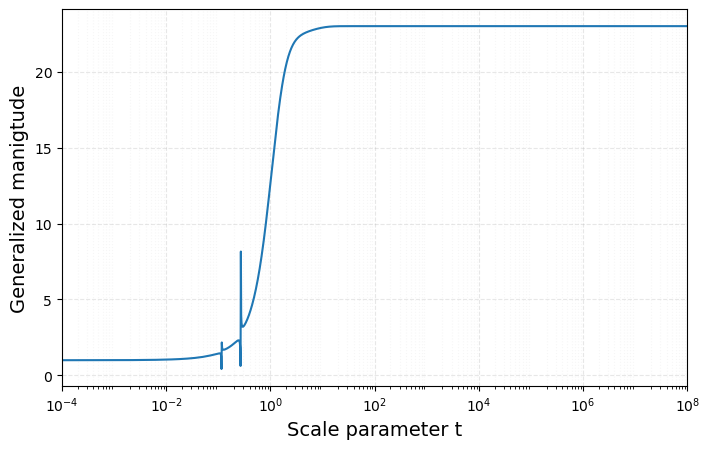

/home/jovyan/work/fig/mean/Generalized manigtude_sub0.png


In [9]:
out = viz.plt_metric_single(
    metric_df=genmag_mean,
    subject=0,
    metric_name="Generalized magnitude",
    output_dir=figpath,
    positive_definite_df=None,
    posdef_mode="two_color",   # or "true_only"
)
print(out)

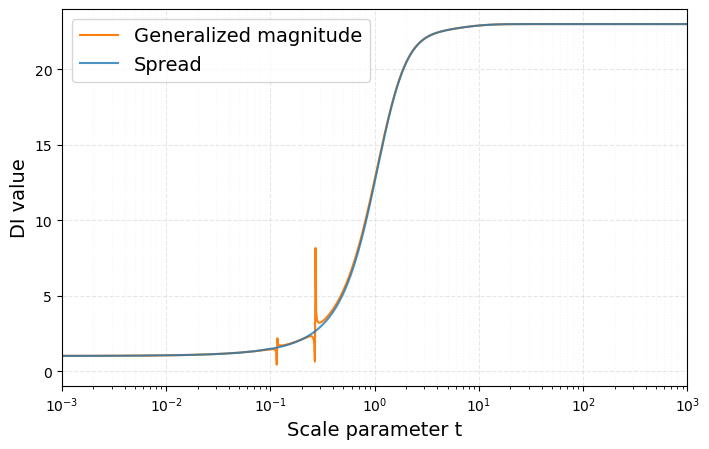

In [6]:
figsize = (7.2, 4.6)
xlim = [0.001, 1000]
ylim = [-1, 24]

fig, ax = plt.subplots(figsize=figsize)

t_sorted = [pd.to_numeric(genmag_mean.columns).to_numpy(),
            pd.to_numeric(spr_mean.columns).to_numpy()]
y = [np.squeeze(genmag_mean.to_numpy()), np.squeeze(spr_mean.to_numpy())]
ax.plot(t_sorted[0], y[0], label="Generalized magnitude", color="tab:orange")
ax.plot(t_sorted[1], y[1], label="Spread", color="tab:blue", alpha=0.8)

ax.set_xscale("log")
ax.set_xlim(*xlim)
ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=6))
ax.xaxis.set_major_formatter(LogFormatterMathtext(base=10.0))
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=100))
ax.xaxis.set_minor_formatter(NullFormatter())
ax.grid(True, which="major", linestyle="--", alpha=0.3)
ax.grid(True, which="minor", linestyle=":", alpha=0.1)

ax.set_ylim(ylim)

ax.set_xlabel("Scale parameter t", fontsize=14)
ax.set_ylabel("DI value", fontsize=14)
ax.legend(fontsize=14)

fig.tight_layout()

out_png = os.path.join(figpath, "DIs_mean.png")
fig.savefig(out_png, dpi=300, bbox_inches="tight")